<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_11_2D_Laplace_Equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 11: 2D Laplace Equation

In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def plot2D(x,y,p):  # define a function for visulizing 2d plot
    fig = plt.figure(figsize = (11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    # The '111' means a grid of 1 row and 1 column and this subplot is the first one.
    X, Y = np.meshgrid(x,y)
    surf = ax.plot_surface(X,Y,p,cmap=cm.viridis)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

In [3]:
def laplace2d(p, y, dx, dy, l1norm_target):
    l1norm = 1
    pn = np.zeros_like(p)

    while l1norm > l1norm_target:
        pn = p.copy()
        p[1:-1,1:-1] = ((dy**2 * (pn[2:,1:-1] + pn[:-2,1:-1]) +
                        dx**2 * (pn[1:-1,2:] + pn[1:-1,:-2])) /
                        (2 * (dx**2 + dy**2)))
        p[0,:] = 0  # p = 0 @ x = 0
        p[-1:,] = y # p = y @ x = 2
        p[:,0] = p[:,1] # dp/dy = 0 @ y = 0
        p[:,-1] = p[:,-2] # dp/dy = 0 @ y = 2
        l1norm = (np.sum(np.abs(p[:])-np.abs(pn[:])) / np.sum(np.abs(pn[:])))
    return p

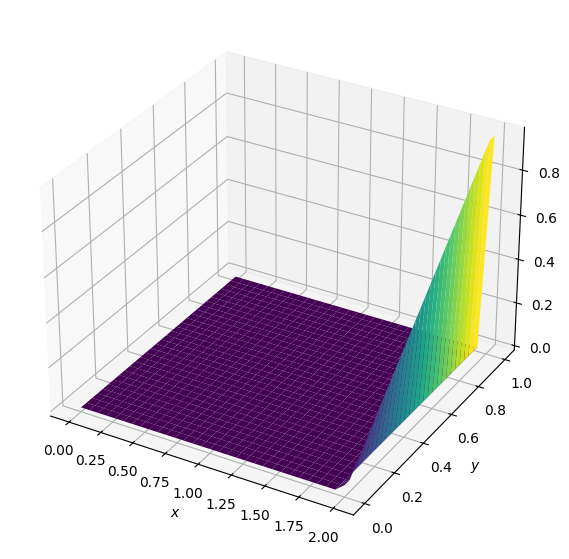

In [4]:
##variable declarations
nx = 31
ny = 31
c = 1
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)


##initial conditions
p = np.zeros((nx, ny))  # create a XxY vector of 0's


##plotting aids
x = np.linspace(0, 2, nx)
y = np.linspace(0, 1, ny)

##boundary conditions
p[:, 0] = 0  # p = 0 @ x = 0
p[:, -1] = y  # p = y @ x = 2
p[0, :] = p[1, :]  # dp/dy = 0 @ y = 0
p[-1, :] = p[-2, :]  # dp/dy = 0 @ y = 1

p_init = p.copy()

#hit the **tab** key for auto-complete options.
plot2D(x,y,p_init)

In [5]:
p = laplace2d(p, y, dx, dy, 1e-4)

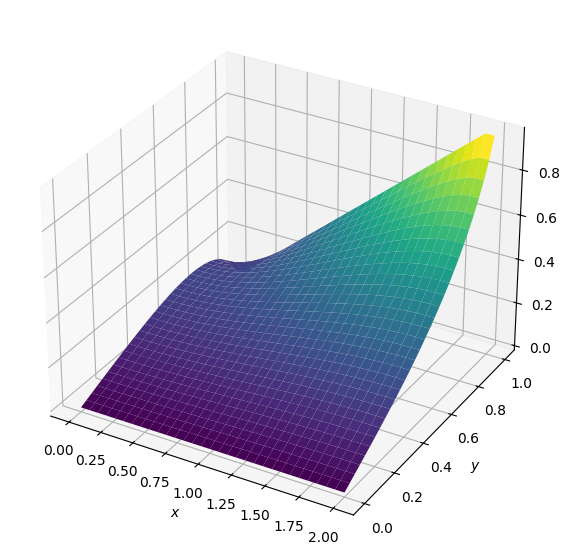

In [6]:
plot2D(x, y, p)